In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from lpips import LPIPS
from pytorch_msssim import SSIM

In [13]:
class TrainImageDataset(Dataset):
    def __init__(self, image_dir) -> None:
        self.image_dir = Path(image_dir)
        self.GT_PATH = self.image_dir / 'GT'  # Assuming GT images are in a subdirectory named 'GT'
        self.NoisyLR_PATH = self.image_dir / 'NoisyLR'  # Assuming NoisyLR images are in a subdirectory named 'NoisyLR'
        self.GT_image_paths = list(self.GT_PATH.glob('*.npy'))  # Assuming images are in .npy format
        self.NoisyLR_image_paths = list(self.NoisyLR_PATH.glob('*.npy'))  # Assuming images are in .npy format
        assert len(self.GT_image_paths) == len(self.NoisyLR_image_paths)

    def __len__(self) -> int:
        return len(self.GT_image_paths)

    def __getitem__(self, idx) -> tuple[np.ndarray, np.ndarray]:
        GT_image = np.load(self.GT_image_paths[idx])  # Load the GT image
        return zoom(GT_image, zoom=0.5, order=3), GT_image  # Return both images

    def refresh(self) -> None:
        self.GT_image_paths = list(self.GT_PATH.glob('*.npy'))
        self.NoisyLR_image_paths = list(self.NoisyLR_PATH.glob('*.npy'))
        assert len(self.GT_image_paths) == len(self.NoisyLR_image_paths)

In [14]:
orginal_train_dataset = TrainImageDataset(image_dir="../data/train/train")
augmented_train_dataset = TrainImageDataset(image_dir="../data/train/augmented_new_noise")
# augmented_test_dataset = TrainImageDataset(image_dir="../data/train/augmented_direct")

dataset = torch.utils.data.ConcatDataset([orginal_train_dataset, augmented_train_dataset])
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [int(len(dataset) * 0.8), len(dataset) - int(len(dataset) * 0.8)])
print("Total dataset size: ", len(dataset))
print("Train dataset size: ", len(train_dataset))
print("Test dataset size: ", len(test_dataset))

# shapes = [(a.shape, b.shape) for a, b in dataset]
# print(set([shape[0] for shape in shapes]), set([shape[1] for shape in shapes]))

Total dataset size:  12800
Train dataset size:  10240
Test dataset size:  2560


In [15]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [18]:
class ESPCN(nn.Module):
    def __init__(self, scale_factor, num_channels=1):
        super(ESPCN, self).__init__()
        
        # Feature extraction
        self.conv1 = nn.Conv2d(num_channels, 64, kernel_size=5, padding=2)
        self.tanh1 = nn.Tanh()
        
        # Non-linear mapping
        self.conv2 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.tanh2 = nn.Tanh()
        
        # Sub-pixel convolution layer
        self.conv3 = nn.Conv2d(32, num_channels * (scale_factor ** 2), kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale_factor)

    def forward(self, x):
        x = self.tanh1(self.conv1(x))
        x = self.tanh2(self.conv2(x))
        x = self.pixel_shuffle(self.conv3(x))
        return x

In [17]:
def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train()
    loss_history = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.float().to(DEVICE), targets.float().to(DEVICE)  # Ensure the data is in float format
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(train_loader):.4f}")
        loss_history.append(running_loss / len(train_loader))

    return loss_history

Epoch [1/10], Loss: 0.1474
Epoch [2/10], Loss: 0.1464
Epoch [3/10], Loss: 0.1475
Epoch [4/10], Loss: 0.1462
Epoch [5/10], Loss: 0.1459
Epoch [6/10], Loss: 0.1457
Epoch [7/10], Loss: 0.1461
Epoch [8/10], Loss: 0.1453
Epoch [9/10], Loss: 0.1464
Epoch [10/10], Loss: 0.1450


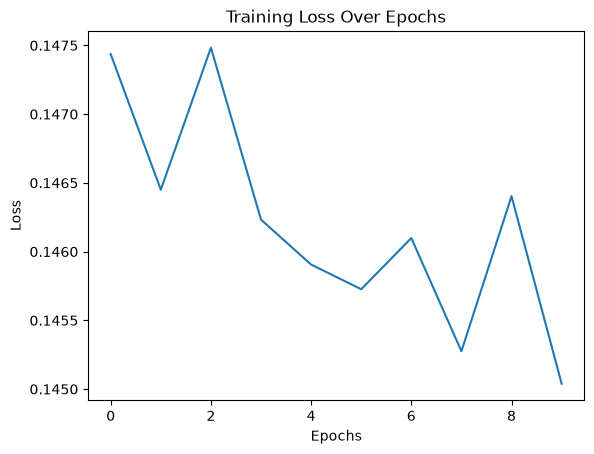

In [30]:
def collate_to_list(batch):
    # Separate data and labels into lists
    data = torch.tensor(np.array([item[0] for item in batch])).unsqueeze(1)  # Add channel dimension for grayscale images
    labels = torch.tensor(np.array([item[1] for item in batch])).unsqueeze(1)  # Add channel dimension for grayscale images
    return data, labels

class CustomLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
        """Charbonnier loss + SSIM loss"""
        super(CustomLoss, self).__init__()
        self.SSIM = SSIM(data_range=1.0, size_average=True, channel=1).to(DEVICE)  # Assuming grayscale images
        self.epsilon = epsilon

    def forward(self, prediction, target):
        diff = prediction - target
        ch_loss = torch.mean(torch.sqrt(diff * diff + self.epsilon * self.epsilon)).to(DEVICE)
        ssim_loss = 1 - self.SSIM(prediction, target).mean().to(DEVICE)
        return ch_loss + ssim_loss

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_to_list, num_workers=4)  # Adjust batch size as needed
model = ESPCN(scale_factor=2, num_channels=1).to(DEVICE)
train_criterion = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # Adjust learning rate as needed
train_loss_history = train_model(model, train_loader, train_criterion, optimizer, num_epochs=10)
# model.load_state_dict(torch.load("../models/restormer_model.pth", map_location=DEVICE))  # Load the model state dict

plt.plot(train_loss_history)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [31]:
torch.save(model.state_dict(), "../models/espcn_model_20.pth")  # Save the model state dict

In [32]:
# measure test loss
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_to_list, num_workers=4)
model.eval()
test_loss = 0.0
#graph test loss over batches       
for batch_idx, (data, target) in enumerate(test_loader):
    data, target = data.to(DEVICE), target.to(DEVICE)
    output = model(data)
    loss = train_criterion(output, target)
    test_loss += loss.item()
test_loss /= len(test_loader)
print(f"Test Loss: {test_loss}")


Test Loss: 0.1445284423782141


Upscaling time for one image: 0.0004 seconds


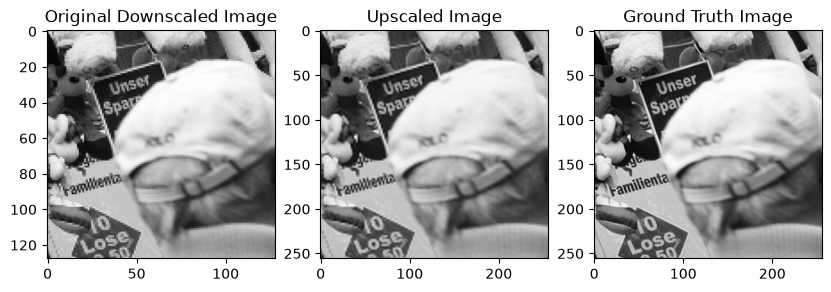

SSIM: 6.300210952758789e-05
Time taken for upscaling: 0.000385284423828125 seconds


In [ ]:
# view a few test images and their predictions
import random
import time

i = random.randint(0, len(test_dataset) - 1)
sample_image = torch.from_numpy(test_dataset[i][0]).unsqueeze(0).unsqueeze(0).to(DEVICE).float()  

time_start = time.time()
restored_image = model(sample_image)
time_end = time.time()
print(f"Upscaling time for one image: {time_end - time_start:.4f} seconds")

fig, axs = plt.subplots(1, 3, figsize=(10, 5))
# Display the original downscaled image
axs[0].imshow(sample_image.squeeze().cpu().numpy(), cmap='gray')
axs[0].set_title("Original Downscaled Image")
# Display the restored image
axs[1].imshow(restored_image.squeeze().detach().cpu().numpy(), cmap='gray')
axs[1].set_title("Upscaled Image")
# Display the ground truth image
axs[2].imshow(test_dataset[i][1], cmap='gray')
axs[2].set_title("Ground Truth Image")
plt.show()

print("SSIM:", 1 - ssim(restored_image, torch.from_numpy(test_dataset[i][1]).unsqueeze(0).unsqueeze(0).to(DEVICE).float()).item())
print("Time taken for upscaling:", time_end - time_start, "seconds")